### The Journey from Sequence-to-Sequence Models to the Transformer

This notebook explores the evolution of models for processing sequential data, from the foundational Encoder-Decoder architecture to the revolutionary Transformer. We will delve into the challenges faced by earlier models, the solutions introduced by the attention mechanism, and the essential components that define modern deep learning in fields like Natural Language Processing.

### 2. The Bottleneck of Seq2Seq Models

#### The Problem Seq2Seq Solves

The Encoder-Decoder architecture, also known as Seq2Seq, was a breakthrough for tasks involving variable-length input and output sequences. It provides a solution to a class of problems that traditional neural networks struggled with.

**Examples of Seq2Seq Tasks:**
* **Machine Translation:** "How are you?" (English sequence) -> "Comment allez-vous ?" (French sequence)
* **Text Summarization:** A long article (text sequence) -> A concise summary (shorter text sequence)
* **Speech Recognition:** Audio waveform (time-series sequence) -> Transcribed text (word sequence)
* **Image Captioning:** An image (can be viewed as a sequence of pixel rows/features) -> A descriptive sentence (word sequence)

The Seq2Seq model tackles this by decoupling the processing of the input and the generation of the output into two distinct neural networks.

#### The Encoder in Seq2Seq

The encoder's primary job is to **read and process the entire input sequence** and compress all its relevant information into a fixed-size numerical representation. This representation is often called the **context vector**, **thought vector**, or **latent representation**.

* **RNN-based Architecture (LSTM/GRU):** Historically, the encoder was a Recurrent Neural Network. It reads the input one element at a time, and its final hidden state becomes the context vector, which ideally encapsulates the "meaning" of the entire input sequence.
* **Transformer-based Architecture:** For modern Seq2Seq models, the encoder is often a Transformer. It processes all input elements in parallel using a mechanism called **self-attention**, creating a rich contextualized representation for each input element.

The encoder's key function is to **understand and summarize** the input, regardless of its original length, into a dense, fixed-dimensional space.

#### The Decoder in Seq2Seq

The decoder's job is to **generate the output sequence**, taking the context vector from the encoder as its primary input. It translates the "thought" from the encoder into the desired output sequence, often element by element.

* **RNN-based Architecture (LSTM/GRU):** The decoder, often an RNN, is initialized with the context vector and generates the output sequence one step at a time.
* **Transformer-based Architecture:** For Transformer-based Seq2Seq, the decoder also uses a Transformer architecture with self-attention layers and, crucially, an **Encoder-Decoder Attention** (or Cross-Attention) layer. This layer allows the decoder to dynamically "attend" to the most relevant parts of the input sequence for generating the current output element.

The decoder's key function is to **generate** a coherent and relevant output sequence, guided by the summary provided by the encoder.

### 3. The Evolution and Importance of Attention

#### The Bottleneck Problem

Early RNN-based Seq2Seq models suffered from a "bottleneck" problem: forcing the entire input sequence into a single, fixed-size context vector meant that for very long sequences, information could be lost.

This led to the invention of the **Attention Mechanism**:

* **Encoder (with Attention):** Instead of just passing the *final* hidden state, the encoder now passes **all** its hidden states (one for each input element) to the decoder.
* **Decoder (with Attention):** At each step of generating an output, the decoder doesn't just rely on a single context vector. Instead, it dynamically calculates "attention scores" or "weights" that indicate how relevant *each part of the input sequence* is to generating the *current* output element. It then creates a **weighted sum** of the encoder's hidden states, forming a **dynamic context vector** that changes for every output step.

#### Why Attention is a Game-Changer:

* **Solves the Bottleneck:** No single fixed-size vector needs to encode everything. The decoder can selectively retrieve information.
* **Handles Long Sequences Better:** The decoder can look far back in the input sequence, improving performance on long inputs.
* **Improved Alignment:** Attention implicitly learns alignments between input and output sequences (e.g., which English words correspond to which French words during translation). This makes the models more accurate and interpretable.

In essence, the Encoder-Decoder architecture, especially when augmented with attention (and culminating in the Transformer architecture), forms the backbone of many advanced AI systems that deal with language, speech, and other sequential data.

### 4. The Core Idea: Attention with Query, Key, and Value

At its core, the attention mechanism allows a neural network to **selectively focus on specific parts of its input sequence**. Instead of processing the entire input as a single, fixed-size "thought vector," attention enables the model to dynamically weigh the importance of different input elements.

This is done using three conceptual vectors for each element in a sequence:
* **Query (Q):** Represents "what I'm looking for" or the current state for which attention is being calculated.
* **Key (K):** Represents "what I have" or the information available from the input sequence.
* **Value (V):** The actual information contained within the input, associated with each Key.

The process typically involves:
1.  **Scoring:** Calculate a similarity score between the Query and each of the Keys.
2.  **Weighting:** Apply a softmax function to these scores to get attention weights. These weights sum to 1 and represent a probability distribution over the input elements.
3.  **Context Vector Creation:** Compute a weighted sum of the Values, using the attention weights. This weighted sum is the "context vector," a dynamic representation containing information from the input weighted by its relevance to the current Query.

### 5. Different Types of Attention Mechanisms

While the core idea is similar, various attention mechanisms differ in *how* they compute the alignment scores and *what information* they use for Queries, Keys, and Values.

* **Bahdanau Attention (Additive Attention):** One of the first and most influential mechanisms. It calculates attention scores by **adding** the (transformed) decoder hidden state (query) and encoder hidden states (keys) before passing them through a feed-forward network. It is generally more complex but can capture nuanced alignments.
* **Luong Attention (Multiplicative Attention):** Simplifies the scoring function, making it more computationally efficient. Its scoring functions involve **multiplying** the decoder hidden state and encoder hidden states, often using a dot product. Luong attention also introduced the concepts of "Global" and "Local" attention.

| Feature | Bahdanau (Additive) Attention | Luong (Multiplicative) Attention |
| :--- | :--- | :--- |
| **Scoring Function** | Additive (Feed-forward network) | Multiplicative (Dot product, General, Concat variants) |
| **Query State** | Previous decoder hidden state ($s_{t-1}$) | Current decoder hidden state ($s_t$) |
| **Context Usage** | Fed as input to the *next* decoder RNN step. | Concatenated with $s_t$ *before* the final output layer. |

### 6\. Introducing the Transformer

#### The Core Idea: Attention Is All You Need

In deep learning, **Transformers** are a revolutionary neural network architecture that have significantly advanced the field, particularly in Natural Language Processing (NLP). They were introduced in the 2017 paper "Attention Is All You Need" by Vaswani et al., which proposed replacing recurrent and convolutional layers entirely with the attention mechanism.

  * **Traditional RNNs/LSTMs:** These models process data step-by-step, making it difficult to capture long-range dependencies and hindering parallel processing.
  * **Attention's Solution:** The attention mechanism allows the Transformer to "attend" to different parts of the input sequence simultaneously, determining the relevance of each part to the current word or context.

The central innovation of the Transformer is its reliance on **self-attention** and **multi-head attention**.

#### Architecture Components

A typical Transformer architecture consists of:

  * **Encoder:** Processes the input sequence. It is composed of multiple identical layers.
  * **Decoder:** Generates the output sequence. It also has multiple identical layers, but with an additional **Encoder-Decoder Attention** layer.
  * **Positional Encoding:** Since Transformers process sequences in parallel, positional encoding is added to the input embeddings to provide information about the relative or absolute position of each element in the sequence.
  * **Embeddings:** Input text is first converted into numerical representations called tokens, and then into dense vectors called embeddings, which capture semantic meaning.

Here is a visual representation of the Transformer architecture:
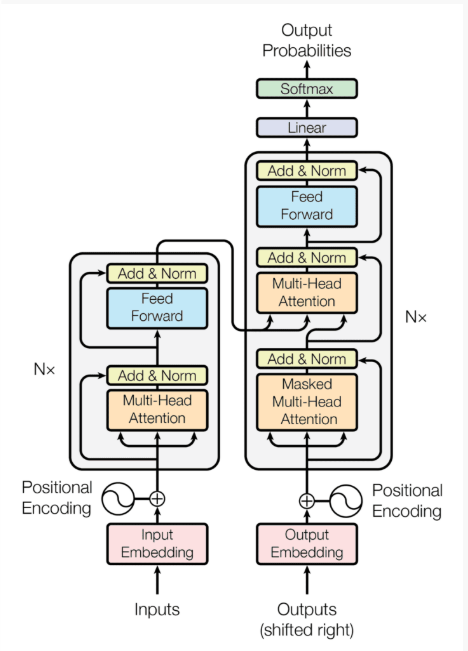

### 7\. The Mechanism of Self-Attention

#### The Core Idea: Contextual Relationships

Self-attention allows a model to understand the relationships between elements **within a single sequence**. For each element, it computes a score of its relevance to *every other element* in that *same sequence*. This allows the model to learn the dependencies and relationships between different positions within the sequence.

**Example:** In the sentence "The animal didn't cross the street because **it** was too tired."
When processing the word "it," self-attention allows the model to "look at" and weigh other words in the sentence (like "animal") to correctly determine what "it" refers to.

#### Simulation: Visualizing Self-Attention

Self-attention is highly interpretable. We can visualize which words a model is "paying attention to" for any given word. A popular tool for this is `bertviz`. The code below uses this library to show the attention patterns for a pre-trained BERT model.

In [1]:
from bertviz.transformers_neuron_view import BertModel, BertTokenizer
from bertviz.neuron_view import show

modelName = 'bert-base-cased'

tokenizer_viz = BertTokenizer.from_pretrained(modelName, do_lower_case = False)
model_viz = BertModel.from_pretrained(modelName, output_attentions=True)

sentence_a = 'My idol is Lionel Messi , he is the greatest player of all time.'

show(model_viz, 'bert', tokenizer_viz, sentence_a, display_mode = 'light', head = 3)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 8. Multi-Head Attention: A Committee of Experts

A single attention mechanism, while powerful, might only be able to capture one type of relationship. For example, it might focus on grammar but miss the semantic relationships.

**Multi-Head Attention** addresses this by performing **several independent attention calculations in parallel**.

#### How it works:
* **Splitting the "Attention":** Instead of one large attention calculation, it performs multiple smaller ones, each called a "head."
* **Different Perspectives:** Each "head" learns to focus on different aspects of the input sequence. It does this by projecting the input Queries, Keys, and Values into different, typically lower-dimensional, subspaces using separate learned transformations.
* **Concatenation and Final Projection:** The outputs from all heads are then **concatenated** and passed through a final **linear transformation** to project it back to the desired output dimension.

#### Analogy: A Committee of Experts

Imagine you have a complex problem to solve.
* **Single Attention Head:** You give the problem to one expert, who gives their best analysis from a single perspective.
* **Multi-Head Attention:** You give the problem to a **committee of experts (the multiple heads)**. Each expert specializes in a different aspect and provides their specialized insights. The outputs from all experts are then combined into a comprehensive final report.

This "committee" approach allows the model to capture a much richer and more nuanced understanding of the input data.

### 9. What is Positional Encoding?

In traditional RNNs, the sequential processing of words provides an inherent sense of order. However, the **Transformer architecture** processes all words in a sequence **simultaneously**. If you simply feed the embeddings of "cat," "chased," and "dog," the Transformer wouldn't know if it's "cat chased dog" or "dog chased cat."

**Positional Encoding** is a mechanism to inject information about the relative or absolute position of tokens in the sequence into the model, without losing the advantages of the self-attention mechanism.

#### How it works:

Positional Encoding works by creating unique numerical vectors (the "positional encodings") for each position in a sequence. These vectors are then **added** to the corresponding word embeddings *before* they are fed into the Transformer.

The most common type of positional encoding used in the original Transformer paper is **sinusoidal positional encoding**.

* **Fixed (Non-Learned):** These encodings are pre-calculated mathematical functions (sine and cosine waves), not learned during training.
* **Captures Relative Position:** The use of sine and cosine functions at different frequencies allows the model to easily learn and compare relative positions. The difference between the positional encoding for position `k` and `k+1` is consistent across the sequence.
* **Extensible:** Because they are based on mathematical functions, these encodings can be generated for sequences longer than those seen during training without issues.
* **Addition:** The positional encoding vector is **added** to the word embedding vector, ensuring that position information is merged directly with the word's semantic information.

The formulas for sinusoidal positional encoding are:
$$PE_{(pos, 2i)} = \sin \left( \frac{pos}{10000^{2i/d_{model}}} \right)$$
$$PE_{(pos, 2i+1)} = \cos \left( \frac{pos}{10000^{2i/d_{model}}} \right)$$

This elegant solution ensures that Transformers do not treat sentences as a "bag of words," thereby preserving crucial grammatical and semantic information conveyed by word order.

### 10. What is Layer Normalization?

Layer Normalization is a technique used to **normalize the inputs to the neurons within a single layer across all features (hidden units) for each individual training example.**

#### Why it's needed:

Layer Normalization, similar to Batch Normalization, helps stabilize the learning process by keeping the distribution of layer inputs consistent. This prevents issues like **Internal Covariate Shift** and helps mitigate **Vanishing/Exploding Gradients**, making training more robust.

#### How it works:

For a single training example, LayerNorm performs the following steps:
1.  **Calculate Mean ($\mu$):** It calculates the mean of all activations *for that one example* within that layer.
2.  **Calculate Variance ($\sigma^2$):** It calculates the variance of all activations *for that one example*.
3.  **Normalize:** Each activation is then normalized using these sample-specific statistics.
    $\hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}}$
4.  **Scale and Shift:** These normalized values are scaled by a learned parameter $\gamma$ and shifted by a learned parameter $\beta$, allowing the network to adjust the normalization.

#### Key Distinction from Batch Normalization:

The crucial difference lies in **which dimension the statistics are calculated over**:
* **Batch Normalization:** Calculates statistics **across the batch dimension** for each feature. This makes it sensitive to batch size.
* **Layer Normalization:** Calculates statistics **across the feature dimension** for each *single example*. It is completely independent of batch size.

This batch size independence is the primary reason Layer Normalization is preferred in Transformers and RNNs, as it allows for stable training with variable-length sequences and small batch sizes. It also provides consistent behavior during both training and inference.

### 11. Masked Multi-Head Attention

Masked multi-head attention is a key component of the Transformer architecture, particularly in the **decoder**. It is a modification of the standard multi-head attention mechanism designed for tasks where a model needs to generate a sequence one token at a time, such as language translation or text generation.

#### The Core Problem: Autoregressive Generation

When a model generates text, it's an autoregressive process. This means that to predict the next word, the model can only use the words it has already generated. It cannot "peek ahead" at future words in the sequence.

For example, if the model is generating the sentence "The cat sat on the mat," when it's predicting "sat," it should only have access to "The" and "cat." It must not be able to see "on," "the," or "mat" to make its prediction. This is where masking comes in.

#### How Masking Works

In a standard self-attention mechanism, every token in a sequence can attend to every other token. Masked attention introduces a "mask" to this process. This mask is a matrix, typically with a lower triangular shape, that modifies the attention scores before the softmax function is applied.

* **Before Softmax:** The attention scores for all future tokens (i.e., those that appear after the current token) are set to a very large negative number (e.g., $-\infty$).
* **After Softmax:** When the softmax function is applied, these large negative numbers become zero. This effectively "masks out" or eliminates the influence of future tokens.

This ensures that for any given token, its representation is a weighted sum of the values of the current and preceding tokens only, preventing the model from using future context.

### 12. Cross-Attention Mechanism

Cross-attention is a crucial component of the Transformer architecture, particularly in the **decoder** part. While self-attention allows a model to understand relationships within a single sequence, cross-attention is designed to connect two different sequences.

#### The Core Idea: Connecting Two Sequences

In a machine translation task, for example, a Transformer encoder processes the entire English sentence, creating a rich, contextual representation for each word. The Transformer decoder then generates the German translation, one word at a time. To generate each German word, it needs to know what it has already generated (using masked self-attention) and, critically, what the **original English sentence was**.

This is where cross-attention comes in. It acts as a bridge, allowing the decoder to "look back" at the encoder's output and selectively focus on the most relevant parts of the English sentence for generating the next German word.

#### How it Works:

The attention mechanism works by calculating an output as a weighted sum of "value" vectors, where the weights are determined by the similarity between "query" and "key" vectors.

In cross-attention, the key difference is the source of these vectors:
* **Query (Q):** Generated from the **decoder's input** (the sequence being generated so far).
* **Key (K) and Value (V):** Generated from the **encoder's output** (the contextualized representation of the original input sentence).

This mechanism allows the model to dynamically align the words in the output sequence with the most relevant words in the input sequence.

#### Cross-Attention vs. Self-Attention

| Feature | Self-Attention | Cross-Attention |
| :--- | :--- | :--- |
| **Input** | A single sequence. | Two different sequences. |
| **Purpose** | To understand the relationships between elements **within** the same sequence. | To understand the relationships and align elements **between** two different sequences. |
| **Q, K, V Sources** | All three vectors come from the **same** input sequence. | **Q** comes from one sequence, while **K and V** come from another. |
| **Primary Use** | Used in both the encoder and decoder to build contextual representations. | Used exclusively in the decoder to allow it to attend to the encoder's output. |

### 13. Conclusion

The journey from the original Seq2Seq model to the Transformer architecture highlights a fundamental shift in how we approach sequence modeling. By moving away from recurrent networks and embracing the powerful attention mechanism, Transformers were able to overcome the limitations of the "bottleneck" and achieve new levels of performance and scalability. This has made them the foundation for many of today's most advanced AI systems, including large language models like GPT, BERT, and Gemini, which are revolutionizing fields from NLP to computer vision.